In [1]:
# Testing objective function output

import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
import jax.numpy as jnp

## Inputs
eq = desc.io.load("Equilibria/equil_G1600_DESC_fixed_QA.h5")
rhos = np.sqrt(np.linspace(0.1,0.9,5)) # rho = sqrt(s)
alphas = np.linspace(0,2*np.pi,5)
KE_frac = np.array([1]) 
pitch_invs = jnp.linspace(5.8,5.9,2)
N=0
##

eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid_psi = eq._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rhos, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.array([0]), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)
Psi = eq.compute("Psi",grid=grid_psi)
obj = TrappedResonance(eq,rho=rhos,pitch_invs=pitch_invs,KE_frac=KE_frac,alpha=alphas,N=N,Psi=Psi['Psi'])
# grid is set in init of TrappedResonance class
obj.build()
value = obj.compute(eq.params_dict)

Precomputing transforms


In [2]:
print(value)

2.9618396114555294e-12


In [ ]:
# debug cell (restart kernel and run before running optimizer)
import sys
import os
import math

sys.path.insert(0, os.path.abspath("."))
sys.path.append(os.path.abspath("../../../"))
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 20

import desc.io
from desc.grid import LinearGrid, ConcentricGrid
from desc.objectives import (
    ObjectiveFunction,
    FixBoundaryR,
    FixBoundaryZ,
    FixPressure,
    FixIota,
    FixPsi,
    AspectRatio,
    ForceBalance,
    QuasisymmetryBoozer,
    QuasisymmetryTwoTerm,
    QuasisymmetryTripleProduct,
    ObjectiveFromUser,
    GammaC,
    TrappedResonance
)
from desc.optimize import Optimizer
from desc.plotting import (
    plot_grid,
    plot_boozer_modes,
    plot_boozer_surface,
    plot_qs_error,
    plot_boundaries,
    plot_boundary,
)
# load initial equilibrium
# eq_init = desc.io.load("qs_initial_guess.h5") # QI
eq_init = desc.io.load("desc_eq_new_QH_aScaling.h5") # QH

# Specify equilibrium nfp and helicity
# N = -1 # QH helicity
# N = 0 # QA
nfp = eq_init.NFP
s_input = np.linspace(0.1,0.9,3) # surfaces to test, rho = sqrt(s) is calculated below. DESC 

# optimizer = Optimizer("proximal-scipy-bfgs")
optimizer = Optimizer("proximal-lsq-exact")

# indices of boundary modes we want to optimize
idx_Rcc = eq_init.surface.R_basis.get_idx(M=1, N=2)
idx_Rss = eq_init.surface.R_basis.get_idx(M=-1, N=-2)
idx_Zsc = eq_init.surface.Z_basis.get_idx(M=-1, N=2)
idx_Zcs = eq_init.surface.Z_basis.get_idx(M=1, N=-2)
print("surface.R_basis.modes is an array of [l,m,n] of the surface modes:")
print(eq_init.surface.R_basis.modes[0:10])

# boundary modes to constrain
R_modes = np.delete(eq_init.surface.R_basis.modes, [idx_Rcc, idx_Rss], axis=0)
Z_modes = np.delete(eq_init.surface.Z_basis.modes, [idx_Zsc, idx_Zcs], axis=0)

eq_qs_T = eq_init.copy()  # make a copy of the original one
# constraints
constraints = (
    ForceBalance(eq=eq_qs_T),  # enforce JxB-grad(p)=0 during optimization
    FixBoundaryR(eq=eq_qs_T, modes=R_modes),  # fix specified R boundary modes
    FixBoundaryZ(eq=eq_qs_T, modes=Z_modes),  # fix specified Z boundary modes
    FixPressure(eq=eq_qs_T),  # fix pressure profile
    FixIota(eq=eq_qs_T),  # fix rotational transform profile
    FixPsi(eq=eq_qs_T),  # fix total toroidal magnetic flux
)

# Create a grid in (rho, theta, zeta) coordinates
# rho = np.linspace(0.1,0.9,5)
rho=abs(np.sqrt(s_input))
eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq_init._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rho, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.linspace(0, 12 * np.pi, 300), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)
# grid has the number of nodes equal to len(rho)*len(alpha)*length(zeta)

# Grid for QuasisymmetryTripleProduct objective
grid_vol = ConcentricGrid(
    L=eq_init.L_grid,
    M=eq_init.M_grid,
    N=eq_init.N_grid,
    NFP=eq_init.NFP,
    sym=eq_init.sym,
)

# Objective for resonance
objective_fT = ObjectiveFunction(
    (
        QuasisymmetryTripleProduct(eq=eq_qs_T, grid=grid_vol),
        TrappedResonance(eq=eq_qs_T, grid=grid)
    ), 
)

In [ ]:
eq_qs_T, result_T = eq_qs_T.optimize(
    objective=objective_fT,
    constraints=constraints,
    optimizer=optimizer,
    ftol=5e-2,  # stopping tolerance on the function value
    xtol=1e-6,  # stopping tolerance on the step size
    gtol=1e-6,  # stopping tolerance on the gradient
    maxiter=10,  # maximum number of iterations
    options={
        "perturb_options": {"order": 2, "verbose": 0},  # use 2nd-order perturbations
        "solve_options": {
            "ftol": 5e-3,
            "xtol": 1e-6,
            "gtol": 1e-6,
            "verbose": 0,
        },  # for equilibrium subproblem
    },
    copy=False,  # copy=False we will overwrite the eq_qs_T object with the optimized result
    verbose=3,
)

TESTING THE DESC TUTORIAL "DESC_TrappedRes/docs/notebooks/tutorials/basic_optimization.ipynb"

In [ ]:
# Copy the basic_optimization.ipynb code here

%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.size"] = 20

import desc.io
from desc.grid import LinearGrid, ConcentricGrid
from desc.objectives import (
    ObjectiveFunction,
    FixBoundaryR,
    FixBoundaryZ,
    FixPressure,
    FixIota,
    FixPsi,
    AspectRatio,
    ForceBalance,
    QuasisymmetryBoozer,
    QuasisymmetryTwoTerm,
    QuasisymmetryTripleProduct,
)
from desc.optimize import Optimizer
from desc.plotting import (
    plot_grid,
    plot_boozer_modes,
    plot_boozer_surface,
    plot_qs_error,
    plot_boundaries,
    plot_boundary,
)

# load initial equilibrium
eq_init = desc.io.load("qs_initial_guess.h5")

optimizer = Optimizer("proximal-lsq-exact")

# indices of boundary modes we want to optimize
idx_Rcc = eq_init.surface.R_basis.get_idx(M=1, N=2)
idx_Rss = eq_init.surface.R_basis.get_idx(M=-1, N=-2)
idx_Zsc = eq_init.surface.Z_basis.get_idx(M=-1, N=2)
idx_Zcs = eq_init.surface.Z_basis.get_idx(M=1, N=-2)
print("surface.R_basis.modes is an array of [l,m,n] of the surface modes:")
print(eq_init.surface.R_basis.modes[0:10])

# boundary modes to constrain
R_modes = np.delete(eq_init.surface.R_basis.modes, [idx_Rcc, idx_Rss], axis=0)
Z_modes = np.delete(eq_init.surface.Z_basis.modes, [idx_Zsc, idx_Zcs], axis=0)

eq_qs_T = eq_init.copy()  # make a copy of the original one
# constraints
constraints = (
    ForceBalance(eq=eq_qs_T),  # enforce JxB-grad(p)=0 during optimization
    FixBoundaryR(eq=eq_qs_T, modes=R_modes),  # fix specified R boundary modes
    FixBoundaryZ(eq=eq_qs_T, modes=Z_modes),  # fix specified Z boundary modes
    FixPressure(eq=eq_qs_T),  # fix pressure profile
    FixIota(eq=eq_qs_T),  # fix rotational transform profile
    FixPsi(eq=eq_qs_T),  # fix total toroidal magnetic flux
)

# objective
grid_vol = ConcentricGrid(
    L=eq_init.L_grid,
    M=eq_init.M_grid,
    N=eq_init.N_grid,
    NFP=eq_init.NFP,
    sym=eq_init.sym,
)
plot_grid(grid_vol, figsize=(8, 8))

objective_fT = ObjectiveFunction(QuasisymmetryTripleProduct(eq=eq_qs_T, grid=grid_vol))

eq_qs_T, result_T = eq_qs_T.optimize(
    objective=objective_fT,
    constraints=constraints,
    optimizer=optimizer,
    ftol=5e-2,  # stopping tolerance on the function value
    xtol=1e-6,  # stopping tolerance on the step size
    gtol=1e-6,  # stopping tolerance on the gradient
    maxiter=50,  # maximum number of iterations
    options={
        "perturb_options": {"order": 2, "verbose": 0},  # use 2nd-order perturbations
        "solve_options": {
            "ftol": 5e-3,
            "xtol": 1e-6,
            "gtol": 1e-6,
            "verbose": 0,
        },  # for equilibrium subproblem
    },
    copy=False,  # copy=False we will overwrite the eq_qs_T object with the optimized result
    verbose=3,
)

TESTING THE OBJECTIVE FUNCTION VALUE

$ y = \omega_{\zeta} - \omega_{\zeta}^r $

If $|y|<0.5$, this is run:
$
f_{ijr} = A e^{-w ( (y+0.5)^2 + (y+0.5) )^t}
$
Otherwise, 
$
f_{ijr} = 0
$

$ f_{ij} = \sum_{r=1}^{N_r} (f_{ijr}) $, $N_r = $ number of resonances considered.

In [2]:
# With two pitch inverses and three surfaces considered. Use desc_eq_new_QH_aScaling.h5
import numpy as np
# omega_arr = np.array([[-1.35078567e-04, -2.88730399e-05],[-1.21966454e-05, -2.42665365e-06],[-5.19323354e-06, -1.03486556e-06]]) # omegas outputted from first cell in this document (just runnning the objective function)
# omega_arr = np.array([[0.2,0.4,0.9],[-1.4,-0.1,0.01]])
omega_arr = np.array([
    [-1.35078567e-04, -2.88730399e-05],
    [-1.21966454e-05, -2.42665365e-06],
    [-5.19323354e-06, -1.03486556e-06]
    ])

res_arr = np.array([ 0.,          1. ,        -1. ,         0.5   ,     -0.5     ,    2.,
 -2.     ,     3.14159265,  3.14159265]) # resonances outputted from first cell in this document (just runnning the objective function)

In [ ]:
import numpy as np
# Calculate objective function (per surface per pitch angle)
res_broad = res_arr[None,None,:] # make 3D array with res values on axis=2
res_broad = np.broadcast_to(res_broad, (omega_arr.shape[0], omega_arr.shape[1], res_arr.shape[0]))
omega_broad = np.broadcast_to(omega_arr[...,None], (omega_arr.shape[0],omega_arr.shape[1],res_arr.shape[0]))


# [:,:,0] is for all the omegas
# [0,0,:] is for all the resonances
y = omega_broad - res_broad
# print(y[:,:,0])
domega = 0.5 # this value must stay at 0.5 or else the entire function must be modified
condition = np.logical_and(abs(y) < domega, res_broad!=np.pi) # check that corresponding omega value is less than 0.5 away from the resonance and not jnp.pi (unset)
# Set weights
w = 1
t = -1
A = np.ones((np.shape(omega_broad))) * 100 # can set to vary with order of resonance if desired


# fp = np.clip(-500,-w * (( -((y+0.5)**2) + (y+0.5) )**t),500)
# print(omega_broad[0,0,:])
# print(res_broad[0,0,:])
# print(fp[0,0,:])


obj_out1 = np.where(
    condition,
    A * np.exp( np.clip(-w * (( -((y+0.5)**2) + (y+0.5) )**t),-500,500) ),
    0
    ) # need to broadcast res_arr to 3D to match each res with each 2D matrix of omega_arr and then do this subtraction and jnp.where operation

obj_out = np.sum(obj_out1,axis=2) # outputs array with size (rho,pitch)
# # print(res_broad[:,:,0])
num_pitch=2
num_rho = 3
obj_out = np.reshape(obj_out,num_pitch*num_rho)
print(obj_out)

In [ ]:
# Equilibrium Examination
import numpy as np
from desc.equilibrium import Equilibrium
from desc.grid import LinearGrid
import matplotlib.pyplot as plt
eq = Equilibrium.load("desc_eq_beta2.5_QA.h5")
rho = np.array([0.5])

grid_1 = LinearGrid(rho=rho, M=50, N=50, NFP=eq.NFP, endpoint=True)
mod_B_data = eq.compute("|B|", grid=grid_1)
mod_B = mod_B_data["|B|"] # need to shape into 2D array to plot
zeta = (
    grid_1.nodes[:, 2]
    .reshape((grid_1.num_theta, grid_1.num_rho, grid_1.num_zeta), order="F")
    .squeeze()
)
theta = (
    grid_1.nodes[:, 1]
    .reshape((grid_1.num_theta, grid_1.num_rho, grid_1.num_zeta), order="F")
    .squeeze()
)
mod_B = mod_B.reshape(
    (grid_1.num_theta, grid_1.num_rho, grid_1.num_zeta), order="F"
)
# plot contours of |B| on the rho=0.5 surface
plt.figure()
plt.contourf(zeta, theta, mod_B[:, 0, :], cmap="jet")
plt.xlabel(r"$\zeta$")
plt.ylabel(r"$\theta$")
plt.title(r"$|\mathbf{B}|$ on $\rho= $"+str(rho[0])+" surface")
plt.colorbar();
# plt.savefig("modB_rho05.png")
plt.show()



In [ ]:
# Equilibrium output
from desc.equilibrium import Equilibrium
from desc.vmec import VMECIO
eq = Equilibrium.load('equil_Helios_E0092_DESC_fixed.h5')

VMECIO.save(eq=eq,path="wout_equil_Helios_E0092_DESC_fixed.nc")
# VMECIO.write_vmec_input(eq=eq,fname='test')

In [ ]:
from desc.integrals.quad_utils import get_quadrature, automorphism_sin, grad_automorphism_sin, simpson2
from orthax.legendre import leggauss
from desc.backend import jnp, jit

# Set up quadrature points and weights
quad = get_quadrature(
    simpson2(32),  # 32-point Gauss-Legendre quadrature
    (automorphism_sin, grad_automorphism_sin)  # Coordinate transformation
) # this is from negative one to positive one
# Your integrand function (must be JAX-compatible)
data = {
    "a": 0.3,
    "b": 0.7,
    "w": 1.0
}
def my_integrand(data,omega_broad):
    # Your function here - must use JAX operations
    a = data["a"]
    b = data["b"]
    w = data["w"]

    x_transformed = 0.5 * (b - a) * (omega_broad + 1) + a
    # Include Jacobian factor: dx = 0.5 * (b - a) * dx_quad
    jacobian = 0.5 * (b - a)

    # bump_func = jnp.exp( jnp.clip( w * ((a-b)**2) / ( (omega_broad-b) * (omega_broad-a) ) ,-500,500) )
    bump_func = a*b*jnp.sin(x_transformed) * jnp.exp(x_transformed)
    return bump_func, jacobian

# Compute the integral
def compute_integral(data, quad_points, quad_weights):
    # Evaluate integrand at quadrature points
    integrand_values,jacobian = my_integrand(data, quad_points)
    
    # Compute integral using weighted sum
    integral = jnp.sum(integrand_values * quad_weights * jacobian)
    return integral

result = compute_integral(data, quad[0], quad[1])
print(result)

In [2]:
import numpy as np
import desc.io
eq_init = desc.io.load("qs_initial_guess.h5")
rho = np.linspace(0.1,0.9,10)
# rho=abs(np.sqrt(s_input))
eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq_init._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    rho, # radial
    np.array([0]), # poloidal (alpha in this case)
    np.linspace(0, 12 * np.pi, 300), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)

In [ ]:
print(grid)

In [ ]:
import jax.numpy as jnp
import jax

x=jnp.linspace(0,1,1000)
# print(x)
tau=0.01
print(tau*jnp.log(jnp.sum(jnp.exp(    jnp.clip(x/tau,-100,700)    ))))

In [ ]:
import jax
import jax.numpy as jnp
def arr_max_1d(arr):
    # arr_sep = arr[1:,...] - arr[0:-1,...] # examine omega separation of all radial points
    max_num = 99999999999999.9
    max_i = len(arr)+10 # this will throw an error if this function is not written correctly
    i_dumby = 0
    arr_dict = {'arr':arr,'i':i_dumby,'max_num':max_num,'max_i':max_i}
    def body_fun(i,arr_dict):
        cond_dict = {'arr':arr_dict['arr'],
                        'i':i,
                        'max_num':max_num,
                        'max_i':max_i}
        def tb_max(cond_dict):
            cond_dict['max_num'] = cond_dict['arr'][cond_dict['i']]
            cond_dict['max_i'] = cond_dict['i']
            return cond_dict
        def fb_max(cond_dict):
            return cond_dict
        return jax.lax.cond(cond_dict['arr'][i]**2<cond_dict['max_num']**2,tb_max,fb_max,cond_dict)
    out = jax.lax.fori_loop(0,len(arr),body_fun,arr_dict)
    return {'max_i':out['max_i'],'max_num':out['max_num']} # returns a dict with the index of max occurance and the value of the maximum

arr_max_1d_map = jax.vmap(arr_max_1d,in_axes=1,out_axes=0)
omega_arr=np.array([
    [1.,7.,3.,29.,5.],
    [4.,5.,10.,11.,8.]
])
omega_arr_sep = omega_arr[1:,:] - omega_arr[:-1,:]
wd_perpitch = arr_max_1d_map(omega_arr_sep) # not looking at energies right now
wd = arr_max_1d(wd_perpitch['max_num']) # sets half-width of bump function based on resolution
wd = wd['max_num']
# testing

print(omega_arr_sep)
print(wd_perpitch)

In [ ]:
import matplotlib.pyplot as plt

fig,ax = plt.subplots(nrows=1,ncols=3)
ax[2].plot(3,4,label='340000000000000000')
ax[2].plot(6,7,label='67')
ax[2].legend(loc='upper left',bbox_to_anchor=(-1.46, 1.15))

In [ ]:
import numpy as np
B = np.linspace(5,7,20)
lam = B**(-1)
print(lam[1:]-lam[0:-1])

print(lam)

In [ ]:
import desc.io
from desc.objectives import (
    TrappedResonance
)
import numpy as np
import jax.numpy as jnp

eq = desc.io.load("equil_G1600_DESC_fixed.h5")
eq_periodicity = (np.inf,np.inf,np.inf) # periodicity in zeta for these equilibrium to make rtz grid
grid = eq._get_rtz_grid( # returns rho, theta, zeta coordinate grid
    np.linspace(0.1,0.9,10), # radial
    np.array([0]), # poloidal (alpha in this case)
    np.array([0]), # toroidal (zeta in this case)
    coordinates="raz", # rho, alpha, zeta input coordinates
    period=eq_periodicity, # periodicity of coordinate (rho,alpha,zeta)
)
## Inputs
Psi = eq.compute("Psi",grid=grid)
print(Psi['Psi'].shape)


[[4.95278995 5.59824797 6.24370599 6.88916401 7.53462203]]


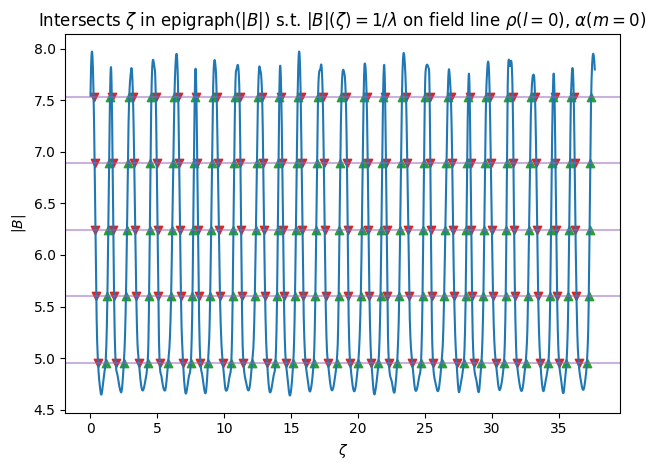

In [5]:
from desc.integrals.bounce_integral import Bounce1D
from desc.equilibrium.coords import get_rtz_grid
import numpy as np
import desc.io

eq = desc.io.load("/Users/paullab/codes/Equilibria/APS 2025 Poster/QI/desc_eq2_wout_betaSQuIDhs.h5")

# Plot one field line
rho = np.array([0.9])
alpha = np.array([1])
zeta = np.linspace(0, 12 * np.pi, 150)
#Convert above coordinates to DESC computational coordinates.
grid = get_rtz_grid(eq, rho, alpha, zeta, coordinates="raz")
# Compute input data.
data = eq.compute(
    Bounce1D.required_names + ["min_tz |B|", "max_tz |B|", "g_zz"], grid=grid
)
# Make the bounce integration operator.
bounce1 = Bounce1D(grid.source_grid, data, check=True)
pitch_inv, _ = bounce1.get_pitch_inv_quad(
    min_B=grid.compress(data["min_tz |B|"]),
    max_B=grid.compress(data["max_tz |B|"]),
    num_pitch=5, # currently pitch is manually set in this function
)
l=0
m=0
print(pitch_inv)
fig, ax = bounce1.plot(l, m, pitch_inv[l], include_legend=False, show=True) # field line plot

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

omega_eta_FIRM3D = np.load('../../../../firm3d_fork_10132025/firm3d/examples/trapped_map/data/omega_eta_FIRM3D_QH.npy')
s_prof_FIRM3D = np.load('../../../../firm3d_fork_10132025/firm3d/examples/trapped_map/data/s_prof_FIRM3D_QH.npy')
omega_eta_DESC = np.load("omega_QHaScaling.npy")
rhos_DESC = np.load("rhos_QHaScaling.npy")

def npmean_nz(x,axis=0):
    mask = x!=0.0
    count = np.sum(mask,axis) # how many wells that are not 0
    return np.sum(x,axis=axis) / count

omega_eta_DESC = npmean_nz(omega_eta_DESC,axis=3)

fig,ax=plt.subplots()
plt.plot(s_prof_FIRM3D**0.5,omega_eta_FIRM3D,label="FIRM3D")
plt.plot(rhos_DESC,-omega_eta_DESC[:,0,0],label="DESC")
plt.legend()

print(value['iotas'])


In [ ]:
from desc.integrals.bounce_integral import Bounce1D
from desc.equilibrium.coords import get_rtz_grid
import numpy as np
import desc.io

eq = desc.io.load("Equilibria/equil_G1600_DESC_fixed_QA.h5")

# Plot one field line
rho = np.linspace(0.01,0.99,50)
alpha = np.array([0])
zeta = np.linspace(0, 8 * np.pi, 50)
#Convert above coordinates to DESC computational coordinates.
grid = get_rtz_grid(eq, rho, alpha, zeta, coordinates="raz")
# Compute input data.
data = eq.compute(
    Bounce1D.required_names + ["min_tz |B|", "max_tz |B|", "g_zz"], grid=grid
)
print('ModB Min: ',np.min(data['min_tz |B|']))
print('ModB Max: ',np.max(data['max_tz |B|']))

In [16]:
# Energy comparison plot

# Setup energies
KE_frac = np.array([1e-5,1e-4,1e-3,1e-2,1e-1,4e-1,7e-1,1])
m_alpha = 6.6446573450*10**(-27) # kg, mass of alpha particle
e = 1.602*10**(-19) # C
Z=2 # fully ionized alpha particle
KE = KE_frac * 5.6076*10**(-13) # J, 3.5 MeV if KE_frac=1
v2 = 2*KE/m_alpha # m/s

def npmean_nz(x,axis=0):
    mask = x!=0.0
    count = np.sum(mask,axis) # how many wells that are not 0
    return np.sum(x,axis=axis) / count

# Average over well and alpha and only consider first pitch
# print(value['omega_arr_noE'].shape)
omega_meanWellAlpha = value['omega_arr_noE'][:,:,0,:]
omega_meanWellAlpha = npmean_nz(omega_meanWellAlpha,axis=-1)
omega_meanWellAlpha = np.mean(omega_meanWellAlpha,axis=1)
# print(omega_meanWellAlpha.shape)

# Expand for energy multiplication
omega_energies = np.broadcast_to(omega_meanWellAlpha[...,None],(omega_meanWellAlpha.shape[0],len(KE_frac)))
v2 = np.broadcast_to(v2[None,...],(omega_meanWellAlpha.shape[0],len(KE_frac)))
omega_energies = omega_energies * v2
np.save('G1600_omega_KEs',omega_energies) # := rho,KE

In [2]:
# Changing boundary modes test
import desc.io
eq00 = desc.io.load("Equilibria/desc_eq_beta2.5_QA.h5") 

# eq00 = get("precise_QA")

surf = eq00.surface.copy()
idx_Rcc = surf.R_basis.get_idx(M=1, N=2)
# print(surf.R_lmn[idx_Rcc]) # 0.0439022...
surf.R_lmn[idx_Rcc] = 0.044

eq_new = eq00.copy()
eq_new.surface = surf
eq_new.axis = surf.get_axis()
eq_new.set_initial_guess()

print("surface.R_basis.modes is an array of [l,m,n] of the surface modes:")
print(eq_new.surface.R_basis.modes[0:10])

eq_new.solve(maxiter=15, verbose=3, ftol=1e-3)

surface.R_basis.modes is an array of [l,m,n] of the surface modes:
[[  0 -15 -12]
 [  0 -14 -12]
 [  0 -13 -12]
 [  0 -12 -12]
 [  0 -11 -12]
 [  0 -10 -12]
 [  0  -9 -12]
 [  0  -8 -12]
 [  0  -7 -12]
 [  0  -6 -12]]
Building objective: force
Precomputing transforms
Timer: Precomputing transforms = 1.06 sec
Timer: Objective build = 2.10 sec
Building objective: lcfs R
Building objective: lcfs Z
Building objective: fixed Psi
Building objective: fixed pressure
Building objective: fixed iota
Building objective: fixed sheet current
Building objective: self_consistency R
Building objective: self_consistency Z
Building objective: lambda gauge
Building objective: axis R self consistency
Building objective: axis Z self consistency
Timer: Objective build = 863 ms
Timer: LinearConstraintProjection build = 7.32 sec
Number of parameters: 4321
Number of objectives: 25088
Timer: Initializing the optimization = 12.4 sec

Starting optimization
Using method: lsq-exact
   Iteration     Total nfev       

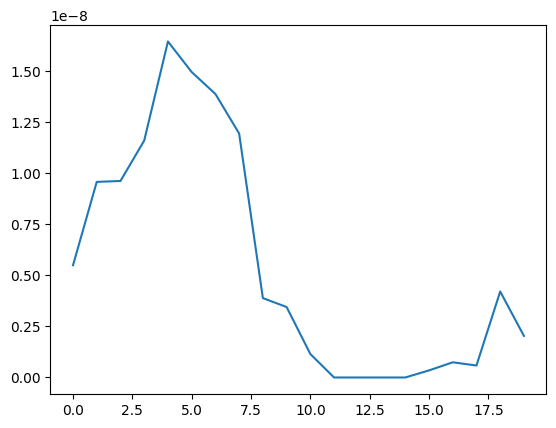

In [6]:
import matplotlib.pyplot as plt
import numpy as np

desc_out = np.load('/Users/paullab/codes/Objective Function Testing/output_data/tr_perpitch_G1600.npy')
plt.plot(desc_out)